[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mpinaz/Thesis/blob/main/Model.ipynb)

# Librerie

In [4]:
!pip install obspy
!git clone https://github.com/Mpinaz/Thesis.git

fatal: destination path 'Thesis' already exists and is not an empty directory.


In [62]:
from obspy import read, Stream, UTCDateTime
from scipy.signal import stft

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from tqdm import tqdm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score, classification_report, f1_score

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px

import numpy as np
import pickle as pk
import copy
from collections import Counter, defaultdict
import pandas as pd

rng = np.random.default_rng(42)
rng_torch = torch.Generator().manual_seed(42)

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Preparing Dataset

In [7]:
catalog = pd.read_csv(
    '/content/Thesis/KVG_catalog.txt',
    sep=',',
    header=None,
    names=['time', 'lat', 'lon', 'depth_km', 'mag'],
)
catalog['time'] = pd.to_datetime(catalog['time'])
catalog['index'] = [f"Event {i}" for i in range(1,len(catalog)+1)]
catalog = catalog.set_index("index")


print(f"Loaded {len(catalog)} events")
catalog.head()

Loaded 11209 events


,time,lat,lon,depth_km,mag
index,,,,,
Event 1,2015-08-03 14:56:47.810000+00:00,56.051729,160.607292,30.49,1.42
Event 2,2015-08-05 02:33:26.280000+00:00,56.027136,160.655599,31.35,2.01
Event 3,2015-08-06 02:11:34.860000+00:00,56.038220,160.563005,29.36,1.97
Event 4,2015-08-06 08:01:51.920000+00:00,56.051261,160.605957,29.73,1.96
Event 5,2015-08-06 10:07:05.340000+00:00,56.067623,160.550732,43.55,1.86


In [83]:
# 90000 Registrations Pre Eruption
with open("/content/drive/MyDrive/Datasets/Pre_Events.pkl", "rb") as f:
    pre = pk.load(f)
PRE_set = {E for St, E, Reg in pre}

with open("/content/drive/MyDrive/Datasets/Feb_Apr_Events.pkl", "rb") as f:
    Feb_Apr = pk.load(f)
FA_set = {E for St, E, Reg in pre}

# 4649 Registrations Post Eruption
with open("/content/drive/MyDrive/Datasets/Post_Events.pkl", "rb") as f:
    post = pk.load(f)
POST_set = {E for St, E, Reg in post}

In [10]:
# Per Esempio fisso mettere la variabile a True, altrimenti False
FIXED = False

per_evento = defaultdict(list)
for St, E, Reg in pre:
    per_evento[E].append((St, E, Reg))

eventi = list(per_evento.keys())

rng.shuffle(eventi)


Data = []
eventi_usati = []

for i , E in enumerate(eventi):
    if len(Data) >= 4640 * 2:
        break
    Data.extend(per_evento[E])
    eventi_usati.append(E)

Events = Data + post

Events = [(St, E, D) for (St, E, D) in Events if len(D) == 3 and all(tr.stats.npts >= 1000 for tr in D)]

print(f"Registrazioni Totali: {len(Events)}\nDati Pre Eruzione: {len(Data)}\nDati Post Eruzione {len(post)}")

Registrazioni Totali: 13937
Dati Pre Eruzione: 9288
Dati Post Eruzione 4649


In [11]:
X = np.arange(len(Events))
y = np.array([1 if E in POST_set else 0 for (St, E, D) in Events])

groups_ev = np.array([E for (St, E, D) in Events])

def split_per_gruppo(groups):
    Train_Test_Shuffle = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    tr, tmp = next(Train_Test_Shuffle.split(X, y, groups))

    Val_Test_Shuffle = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
    v, te = next(Val_Test_Shuffle.split(X[tmp], y[tmp], groups[tmp]))
    val, test = tmp[v], tmp[te]
    return tr, val, test

train_idx, val_idx, test_idx = split_per_gruppo(groups_ev)

# recupero dati
train = [Events[i] for i in train_idx]
val   = [Events[i] for i in val_idx]
test  = [Events[i] for i in test_idx]

In [12]:
assert set(groups_ev[train_idx]).isdisjoint(groups_ev[val_idx])
assert set(groups_ev[train_idx]).isdisjoint(groups_ev[test_idx])
assert set(groups_ev[val_idx]).isdisjoint(groups_ev[test_idx])

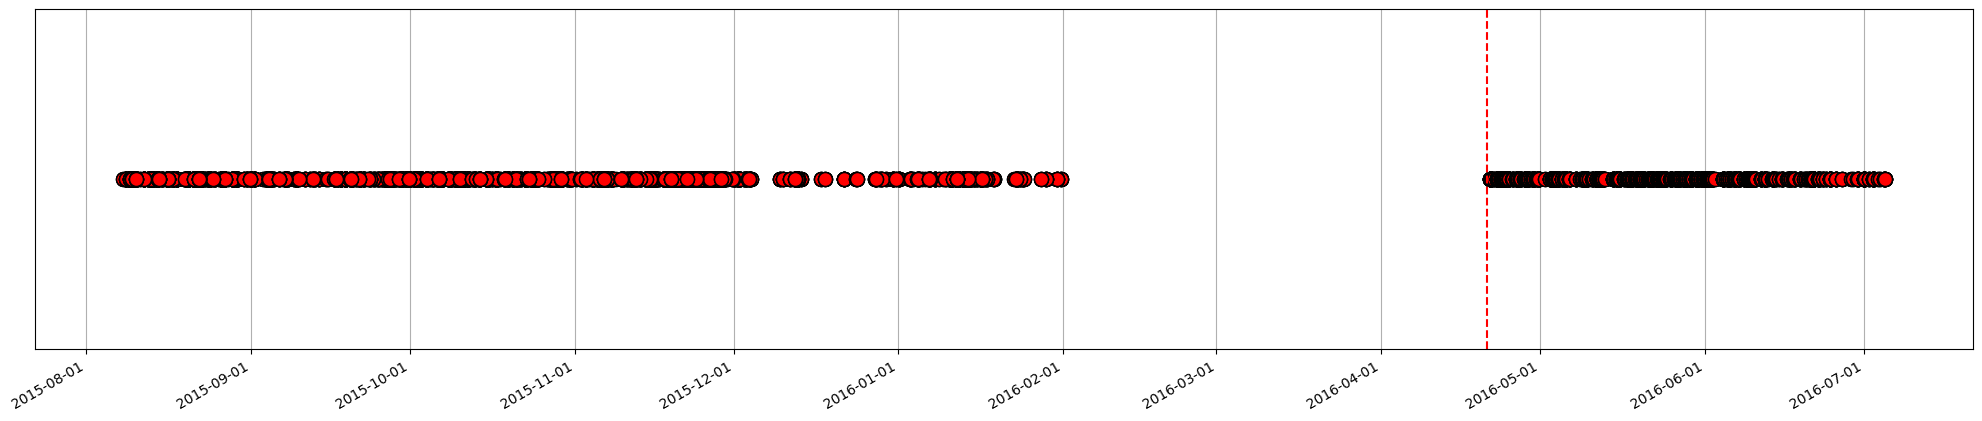

In [13]:
tempi = catalog.loc[groups_ev, "time"]

fig, ax = plt.subplots(figsize=(25, 5))
ax.plot(tempi, [0]*len(tempi), "o",color = "red", ms = 10, markeredgecolor="black", markeredgewidth=1)
ax.yaxis.set_visible(False)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"),)
ax.axvline(pd.Timestamp("2016-04-21", tz="UTC") , color="red", linestyle="--")
ax.grid("on")
fig.autofmt_xdate()
# fig.savefig(f"{Using}: temporal.png", dpi=150, bbox_inches="tight")
plt.show()

train: Eventi Post = 3758, Eventi Pre = 7360, Proporzione eventi post = 0.338
val: Eventi Post = 449, Eventi Pre = 997, Proporzione eventi post = 0.311
test: Eventi Post = 442, Eventi Pre = 931, Proporzione eventi post = 0.322


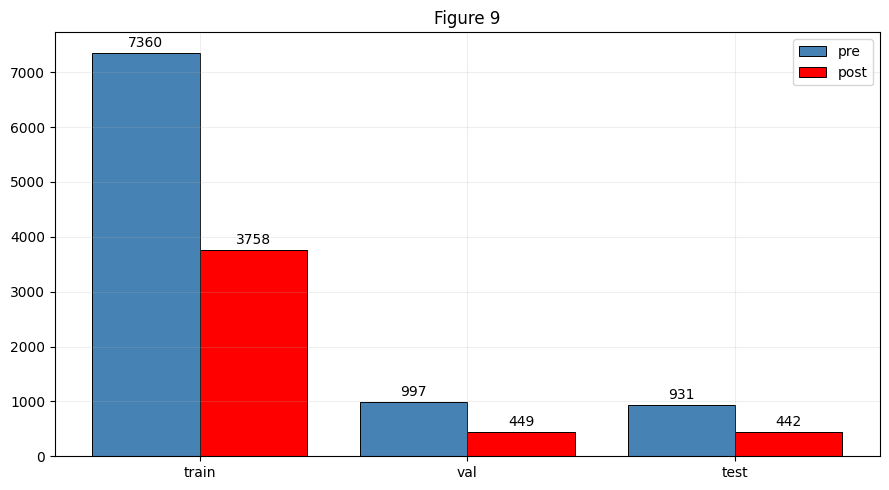

In [14]:
fig2, ax = plt.subplots(figsize=(9, 5))
w = 0.4

for i, (nome, idx) in enumerate([("train", train_idx), ("val", val_idx), ("test", test_idx)]):
    lab = y[idx]
    n_post = int(lab.sum())
    n_pre  = int(len(lab) - lab.sum())
    print(f"{nome}: Eventi Post = {n_post}, Eventi Pre = {n_pre}, Proporzione eventi post = {lab.mean():.3f}")

    b1 = ax.bar(i - w/2, n_pre,  w, color="steelblue", label="pre"  if i == 0 else None, edgecolor="black", linewidth=0.7)
    b2 = ax.bar(i + w/2, n_post, w, color="red",       label="post" if i == 0 else None, edgecolor="black", linewidth=0.7)
    ax.bar_label(b1, padding=2)
    ax.bar_label(b2, padding=2)

ax.set_xticks(range(3))
ax.set_xticklabels(["train", "val", "test"])
ax.set_title("Figure 9")
ax.legend()
ax.grid("on", alpha = 0.2)

fig2.tight_layout()
# fig2.savefig("Figure 9 (Train/Val/Test Splits).png", dpi=150)
plt.show()

# CNN1D

In [15]:
class WaveDataset(Dataset):
    def __init__(self, events, labels, target_len=1000):
        self.events = events
        self.labels = labels
        self.target_len = target_len

    def __len__(self):
        return len(self.events)

    def __getitem__(self, i):
        St, E, D = self.events[i]
        arr = np.stack([tr.data[:self.target_len] for tr in D]).astype(np.float32)

        # normalizzazione per traccia
        arr = arr - arr.mean(axis=1, keepdims=True)
        std = arr.std(axis=1, keepdims=True)
        arr = arr / (std + 1e-8)

        x = torch.from_numpy(arr)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y

In [16]:
train_ds_W = WaveDataset([Events[i] for i in train_idx], y[train_idx])
val_ds_W   = WaveDataset([Events[i] for i in val_idx],   y[val_idx])
test_ds_W  = WaveDataset([Events[i] for i in test_idx],  y[test_idx])


train_loader_Wave = DataLoader(train_ds_W, batch_size=32, shuffle=True, generator = rng_torch) # Togliere Generator per randomness
val_loader_Wave   = DataLoader(val_ds_W,   batch_size=32)
test_loader_Wave  = DataLoader(test_ds_W,  batch_size=32)

In [17]:
class CNN(nn.Module):
    def __init__(self, input_channels=3, output_classes=2):
        super().__init__()
        self.p = 0.15
        self.features = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.MaxPool1d(2),
            nn.ReLU(),

            nn.Dropout(self.p),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),
            nn.ReLU(),

            nn.Dropout(self.p),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(2),
            nn.ReLU(),


            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )
        self.lin = nn.Linear(256, output_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.lin(x)

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Epochs = 100
OneD_model = CNN().to(device)

class_weights = torch.tensor([1.0, 2.0], device=device)
crit = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
opt = optim.Adam(OneD_model.parameters(), lr=1e-3)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="min",
    factor=0.5,
    patience=10,
    min_lr=8e-5)

In [19]:
history1D = {"train_loss": [], "val_loss": [],
             "train_acc": [], "val_acc": [],
             "val_bacc": [], "val_f1p": []}
best_val_bacc = 0.0
best_state = None


pbar = tqdm(range(Epochs), desc="Training")
for epoch in pbar:
    OneD_model.train()
    tot_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader_Wave:
        x, y = x.to(device), y.to(device)

        opt.zero_grad()
        out = OneD_model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()

        tot_loss += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)

    train_loss = tot_loss / total
    train_acc  = correct / total

    # Validation

    OneD_model.eval()
    tot_loss, total = 0.0, 0
    val_true, val_pred = [], []
    with torch.no_grad():
        for x, y in val_loader_Wave:
            x, y = x.to(device), y.to(device)
            out = OneD_model(x)
            loss = crit(out, y)

            tot_loss += loss.item() * x.size(0)
            total    += x.size(0)
            val_true.append(y.cpu())
            val_pred.append(out.argmax(1).cpu())

    val_loss = tot_loss / total
    val_true = torch.cat(val_true).numpy()
    val_pred = torch.cat(val_pred).numpy()
    val_acc  = (val_true == val_pred).mean()
    val_bacc = balanced_accuracy_score(val_true, val_pred)
    val_f1p  = f1_score(val_true, val_pred, pos_label=1)

    scheduler.step(val_loss)   # da attivare con lo scheduler

    history1D["train_loss"].append(train_loss)
    history1D["val_loss"].append(val_loss)
    history1D["train_acc"].append(train_acc)
    history1D["val_acc"].append(val_acc)
    history1D["val_bacc"].append(val_bacc)
    history1D["val_f1p"].append(val_f1p)

    if not (epoch + 1) % 25:
          tqdm.write(f"\nEpoch {epoch+1}\ntrain_acc={train_acc:.4f} | val_acc={val_acc:.3f} | val_bacc={val_bacc:.3f} | val_f1p={val_f1p:.3f}")

    if val_bacc > best_val_bacc:
        best_val_bacc = val_bacc
        best_state = copy.deepcopy(OneD_model.state_dict())

OneD_model.load_state_dict(best_state)
print(f"Best val balanced accuracy: {best_val_bacc:.4f}")

Training:  25%|██▌       | 25/100 [01:44<07:46,  6.22s/it]


Epoch 25: train_acc=0.8482 val_acc=0.823 val_bacc=0.838 val_f1p=0.755


Training:  50%|█████     | 50/100 [03:24<02:53,  3.47s/it]


Epoch 50: train_acc=0.8838 val_acc=0.840 val_bacc=0.829 val_f1p=0.756


Training:  75%|███████▌  | 75/100 [04:52<01:24,  3.37s/it]


Epoch 75: train_acc=0.9171 val_acc=0.869 val_bacc=0.853 val_f1p=0.794


Training: 100%|██████████| 100/100 [06:17<00:00,  3.77s/it]


Epoch 100: train_acc=0.9258 val_acc=0.857 val_bacc=0.845 val_f1p=0.780
Best val balanced accuracy: 0.8588


# CNN2D

In [20]:
class SpecDataset(Dataset):
    def __init__(self, events, labels):
        self.events = events
        self.labels = labels

    def __len__(self):
        return len(self.events)

    def __getitem__(self, i):
        St, E, D = self.events[i]

        specs = []
        for tr in D:
            sig = tr.data[:1000]
            _, _, Zxx = stft(sig, fs=50, nperseg=64, noverlap=48)
            S = np.log1p(np.abs(Zxx))
            S = (S - S.mean()) / (S.std() + 1e-8)
            specs.append(S)

        arr = np.stack(specs).astype(np.float32)
        x = torch.from_numpy(arr)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y

In [21]:
y = np.array([1 if E in POST_set else 0 for (St, E, D) in Events])
train_ds_S = SpecDataset([Events[i] for i in train_idx], y[train_idx])
val_ds_S   = SpecDataset([Events[i] for i in val_idx],   y[val_idx])
test_ds_S  = SpecDataset([Events[i] for i in test_idx],  y[test_idx])

train_loader_Spec = DataLoader(train_ds_S, batch_size=32, shuffle=True)
val_loader_Spec   = DataLoader(val_ds_S,   batch_size=32)
test_loader_Spec  = DataLoader(test_ds_S,  batch_size=32)

In [22]:
class CNN2D(nn.Module):
    def __init__(self, input_channels=3, output_classes=2):
        super().__init__()
        self.p = 0.15
        self.features = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.ReLU(),

            nn.Dropout2d(self.p),

            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.ReLU(),

            nn.Dropout2d(self.p),

            nn.Conv2d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.ReLU(),

            # nn.Dropout2d(self.p),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            # nn.MaxPool2d(2),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1)
        )
        self.lin = nn.Linear(256, output_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.lin(x)

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Epochs = 100
TwoD_model = CNN2D().to(device)

weights = torch.tensor([1.0, 2.0], device=device)
crit = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)
opt = optim.Adam(TwoD_model.parameters(), lr=1e-3)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="min",
    factor=0.5,
    patience=10,
    min_lr=8e-5)

In [24]:
history2D = {"train_loss": [], "val_loss": [],
             "train_acc": [], "val_acc": [],
             "val_bacc": [], "val_f1p": []}

best_val_bacc = 0.0
best_state = None

pbar = tqdm(range(Epochs), desc="Training")
for epoch in pbar:
    TwoD_model.train()
    tot_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader_Spec:
        x, y = x.to(device), y.to(device)

        opt.zero_grad()
        out = TwoD_model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()

        tot_loss += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)

    train_loss = tot_loss / total
    train_acc  = correct / total

    # Validation
    TwoD_model.eval()
    tot_loss, total = 0.0, 0
    val_true, val_pred = [], []
    with torch.no_grad():
        for x, y in val_loader_Spec:
            x, y = x.to(device), y.to(device)
            out = TwoD_model(x)
            loss = crit(out, y)

            tot_loss += loss.item() * x.size(0)
            total    += x.size(0)
            val_true.append(y.cpu())
            val_pred.append(out.argmax(1).cpu())

    val_loss = tot_loss / total
    val_true = torch.cat(val_true).numpy()
    val_pred = torch.cat(val_pred).numpy()
    val_acc  = (val_true == val_pred).mean()
    val_bacc = balanced_accuracy_score(val_true, val_pred)
    val_f1p  = f1_score(val_true, val_pred, pos_label=1)

    scheduler.step(val_loss)

    history2D["train_loss"].append(train_loss)
    history2D["val_loss"].append(val_loss)
    history2D["train_acc"].append(train_acc)
    history2D["val_acc"].append(val_acc)
    history2D["val_bacc"].append(val_bacc)
    history2D["val_f1p"].append(val_f1p)

    if not (epoch + 1) % 25:
        tqdm.write(f"\nEpoch {epoch+1}\ntrain_acc={train_acc:.4f} | val_acc={val_acc:.3f} | val_bacc={val_bacc:.3f} | val_f1p={val_f1p:.3f}")

    if val_bacc > best_val_bacc:
        best_val_bacc = val_bacc
        best_state = copy.deepcopy(TwoD_model.state_dict())

TwoD_model.load_state_dict(best_state)
print(f"\nBest val balanced accuracy: {best_val_bacc:.4f}")

Training:  25%|██▌       | 25/100 [08:35<26:07, 20.90s/it]


Epoch 25: train_acc=0.9307 val_acc=0.903 val_bacc=0.921 val_f1p=0.861


Training:  50%|█████     | 50/100 [17:36<17:22, 20.86s/it]


Epoch 50: train_acc=0.9922 val_acc=0.910 val_bacc=0.923 val_f1p=0.869


Training:  75%|███████▌  | 75/100 [26:38<08:36, 20.65s/it]


Epoch 75: train_acc=0.9990 val_acc=0.914 val_bacc=0.921 val_f1p=0.872


Training: 100%|██████████| 100/100 [35:16<00:00, 21.16s/it]


Epoch 100: train_acc=0.9988 val_acc=0.916 val_bacc=0.925 val_f1p=0.875

Best val balanced accuracy: 0.9248


# Results Plots

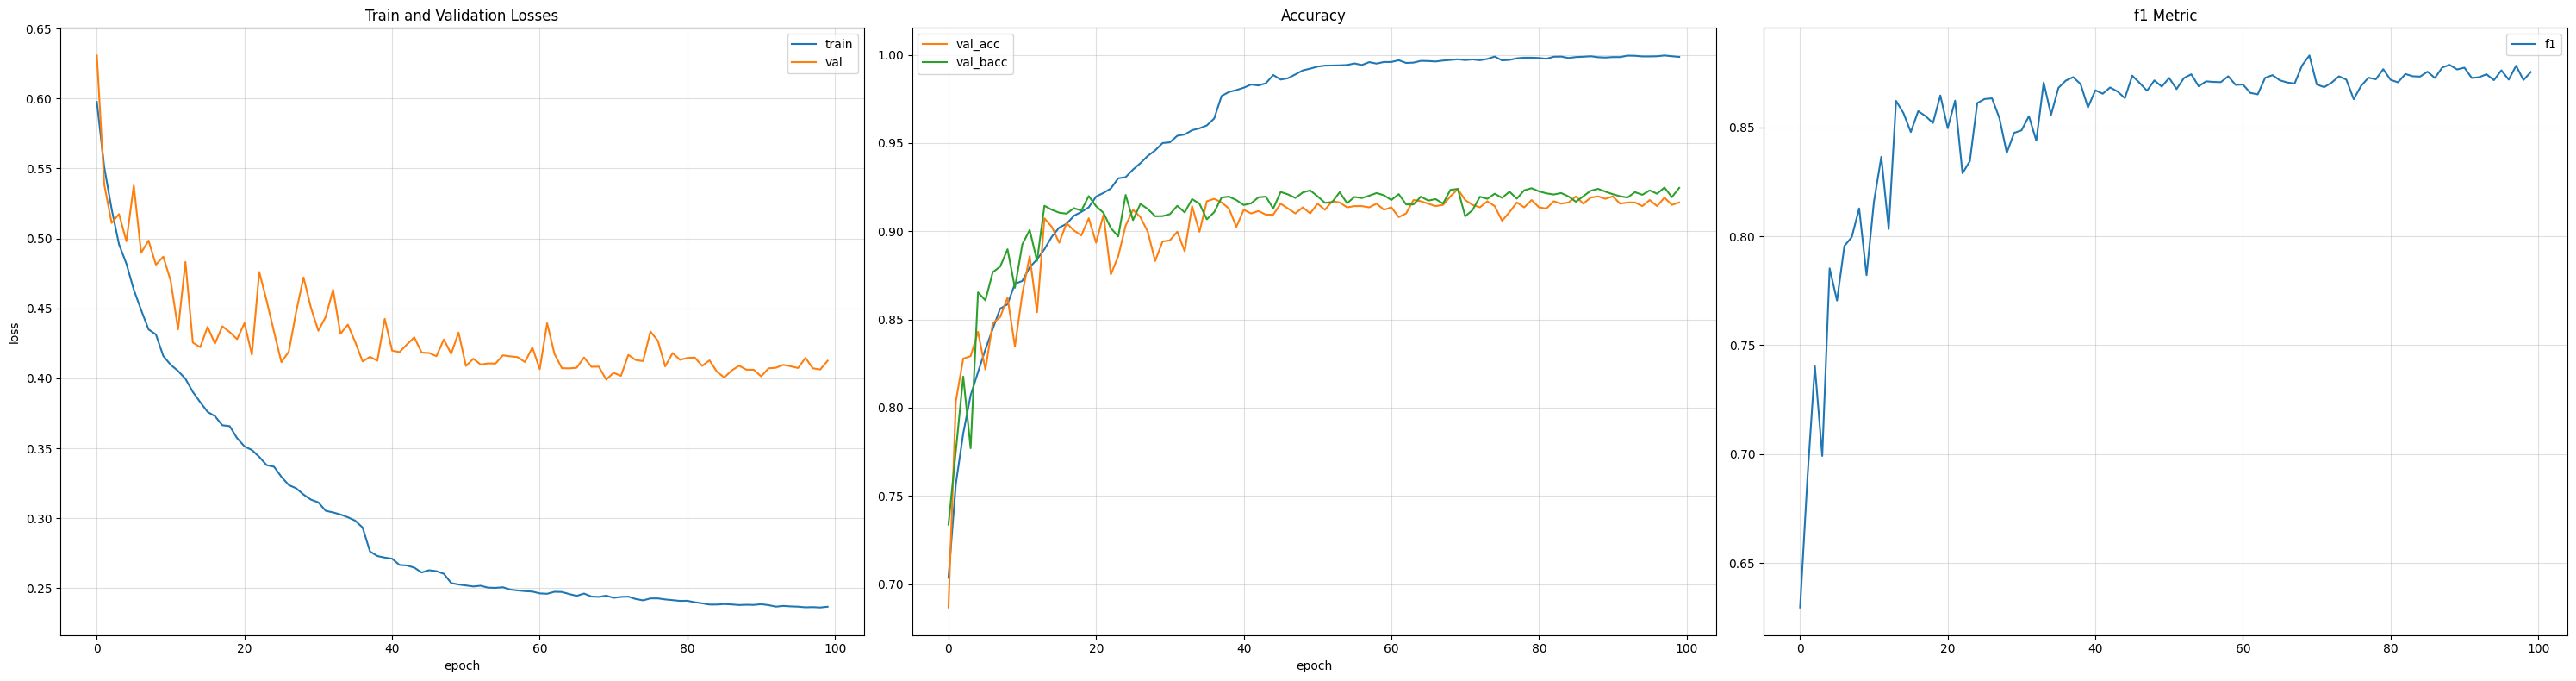

In [101]:
# history, Using, model = history1D, "CNN1D", OneD_model

history, Using, model= history2D, "CNN2D", TwoD_model

fig, ax = plt.subplots(1, 3, figsize=(30, 8))

ax[0].plot(history["train_loss"], label="train")
ax[0].plot(history["val_loss"],   label="val")
ax[0].set_title("Train and Validation Losses")
ax[0].legend()
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("loss")
ax[0].grid(alpha = 0.4)

ax[1].plot(history["train_acc"])
ax[1].plot(history["val_acc"],  label="val_acc")
ax[1].plot(history["val_bacc"], label="val_bacc")
ax[1].set_title("Accuracy")
ax[1].set_xlabel("epoch")
ax[1].grid(alpha = 0.4)
ax[1].legend()

ax[2].plot(history["val_f1p"],  label="f1")
ax[2].set_title("f1 Metric")
ax[2].legend();
ax[2].grid(alpha=0.4)
ax[2].grid(alpha = 0.4)

fig.tight_layout()
# fig.savefig(f"{Using}: Train and Validation set during Training.png", dpi=150, bbox_inches="tight")
plt.show()

In [78]:
def get_preds(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            out = model(x.to(device))
            y_pred.extend(out.argmax(1).cpu().numpy())
            y_true.extend(y.numpy())
    return np.array(y_true), np.array(y_pred)

In [79]:
model.eval()

tst = test_loader_Wave if Using == "CNN1D" else test_loader_Spec
yt, yp = get_preds(model, tst)

print(classification_report(yt, yp, target_names=["pre","post"], digits=3))

              precision    recall  f1-score   support

         pre      0.932     0.820     0.872       931
        post      0.697     0.873     0.775       442

    accuracy                          0.837      1373
   macro avg      0.814     0.846     0.824      1373
weighted avg      0.856     0.837     0.841      1373



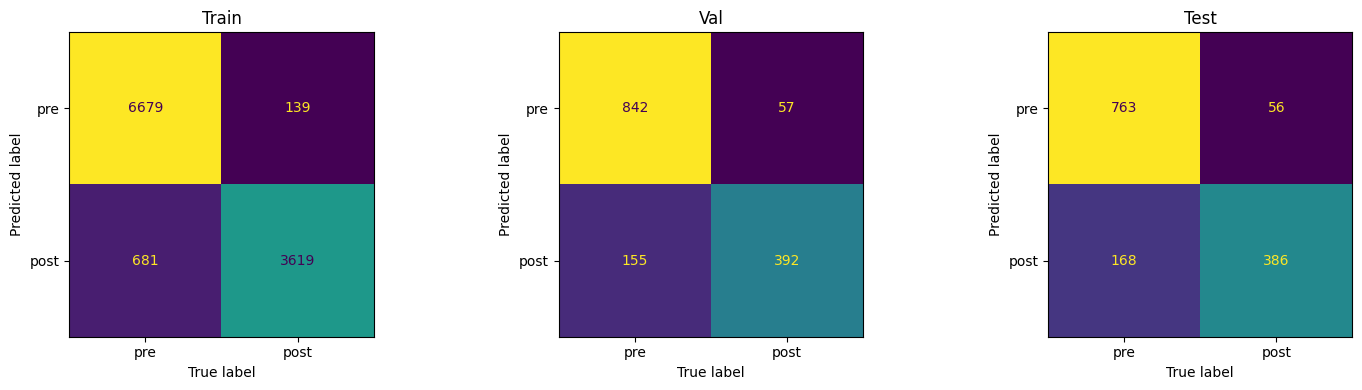

In [80]:
loaders = {"Train": train_loader_Spec, "Val": val_loader_Spec, "Test": test_loader_Spec} if Using == "CNN2D" else {"Train": train_loader_Wave, "Val": val_loader_Wave, "Test": test_loader_Wave}
labels  = ["pre", "post"]
model.eval()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, loader) in zip(axes, loaders.items()):
    yt, yp = get_preds(model, loader)
    cm = confusion_matrix(yt, yp, labels=[0, 1])
    ConfusionMatrixDisplay(cm.T, display_labels=labels).plot(ax=ax, colorbar=False)
    ax.set_xlabel("True label")
    ax.set_ylabel("Predicted label")
    ax.set_title(name)

fig.tight_layout()
# fig.savefig(f"{Using}: Confusion Matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [94]:
mis_idx = np.where(yt != yp)[0]
test_events = test_ds_W.events if Using == "CNN1D" else test_ds_S.events
eventi_test = [test_events[i][1] for i in range(len(test_events))]


tot_per_evento = Counter(eventi_test)
err_per_evento = Counter(test_events[i][1] for i in mis_idx)

df_err = pd.DataFrame({
    "evento": list(tot_per_evento.keys()),
    "registrazioni_totali": [tot_per_evento[e] for e in tot_per_evento],
    "registrazioni_errate": [err_per_evento.get(e, 0) for e in tot_per_evento]})

df_err["Percentuale Errata"] = (df_err["registrazioni_errate"] / df_err["registrazioni_totali"] * 100).round(2)

df_err = df_err[df_err["registrazioni_errate"] > 0].reset_index(drop=True)
df_err = df_err.sort_values(["Percentuale Errata"], ascending = False).reset_index(drop=True)
df_err

IndexError: list index out of range

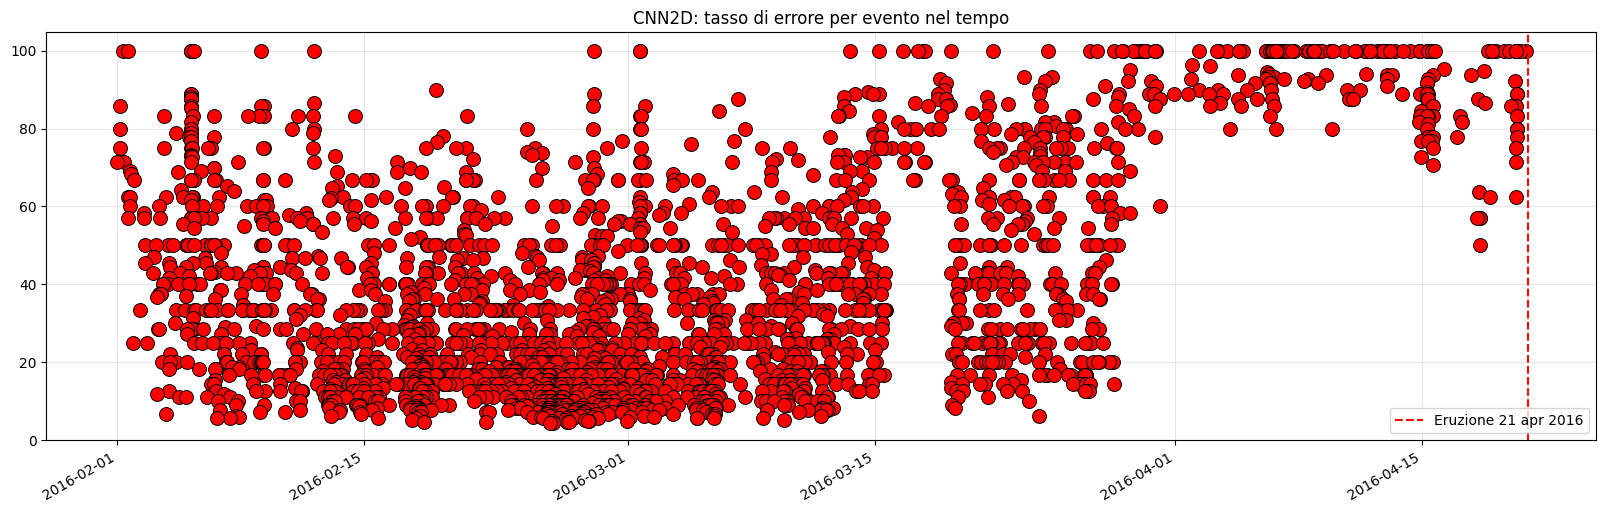

In [105]:
df_err["classe"] = df_err["evento"].apply(lambda e: 1 if e in POST_set else 0)
df_err["time"]   = df_err["evento"].map(catalog["time"])

# separo i due tipi di errore
pre_err  = df_err[df_err["classe"] == 0]   # Falsi Positivi  (pre invece di post)
post_err = df_err[df_err["classe"] == 1]   # Falsi Negativi  (post invece di pre)

fig, ax = plt.subplots(figsize=(20, 6))

# stem: l'altezza = percentuale di errore dell'evento

ax.plot(pre_err["time"], pre_err["Percentuale Errata"], "o",
        color="red", ms=10, markeredgecolor="black", markeredgewidth=0.7)

ax.plot(post_err["time"], post_err["Percentuale Errata"], "o",
        color="steelblue", ms=10, markeredgecolor="black", markeredgewidth=0.7)

ax.axvline(pd.Timestamp("2016-04-21", tz="UTC"), color="red", linestyle="--",
           linewidth=1.5, label="Eruzione 21 apr 2016")


ax.set_ylim(0, None)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.grid(alpha=0.3)
ax.legend()
ax.set_title(f"{Using}: tasso di errore per evento nel tempo")
ax.set_title(f"{Using}: tasso di errore per evento nel tempo")
fig.autofmt_xdate()
# fig.savefig(f"{Using}_temporal_errors.png", dpi=150, bbox_inches="tight")
plt.show()

In [102]:
n = len(Feb_Apr)
labells = [0] * n


FA__SDataset = SpecDataset(Feb_Apr, labells)
FA__WDataset = WaveDataset(Feb_Apr, labells)

FAS = DataLoader(FA__SDataset, batch_size=32)
FAW = DataLoader(FA__WDataset, batch_size=32)

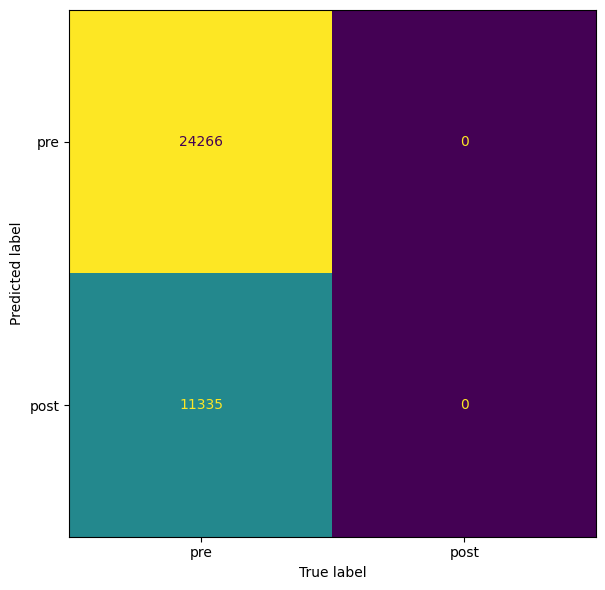

In [103]:
loader = FAS if Using == "CNN2D" else FAW
labels  = ["pre", "post"]
model.eval()

fig, ax = plt.subplots(figsize=(20, 6))

yt, yp = get_preds(model, loader)
cm = confusion_matrix(yt, yp, labels=[0, 1])
ConfusionMatrixDisplay(cm.T, display_labels=labels).plot(ax=ax, colorbar=False)
ax.set_xlabel("True label")
ax.set_ylabel("Predicted label")


fig.tight_layout()
# fig.savefig(f"{Using}: Confusion Matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [106]:
print(classification_report(yt, yp, target_names=["pre","post"], digits=3))

              precision    recall  f1-score   support

         pre      1.000     0.682     0.811     35601
        post      0.000     0.000     0.000         0

    accuracy                          0.682     35601
   macro avg      0.500     0.341     0.405     35601
weighted avg      1.000     0.682     0.811     35601



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.



In [104]:
mis_idx = np.where(yt != yp)[0]
test_events = Feb_Apr
eventi_test = [test_events[i][1] for i in range(len(test_events))]


tot_per_evento = Counter(eventi_test)
err_per_evento = Counter(test_events[i][1] for i in mis_idx)

df_err = pd.DataFrame({
    "evento": list(tot_per_evento.keys()),
    "registrazioni_totali": [tot_per_evento[e] for e in tot_per_evento],
    "registrazioni_errate": [err_per_evento.get(e, 0) for e in tot_per_evento]})

df_err["Percentuale Errata"] = (df_err["registrazioni_errate"] / df_err["registrazioni_totali"] * 100).round(2)

df_err = df_err[df_err["registrazioni_errate"] > 0].reset_index(drop=True)
df_err = df_err.sort_values(["Percentuale Errata"], ascending = False).reset_index(drop=True)
df_err

,evento,registrazioni_totali,registrazioni_errate,Percentuale Errata
0,Event 10689,7,7,100.00
1,Event 7325,7,7,100.00
2,Event 7329,6,6,100.00
3,Event 7424,6,6,100.00
4,Event 10165,4,4,100.00
...,...,...,...,...
2683,Event 8326,21,1,4.76
2684,Event 8983,21,1,4.76
2685,Event 8072,22,1,4.55
2686,Event 8871,23,1,4.35


In [108]:
import plotly.express as px

# uso df_err che hai già: evento, registrazioni_totali, registrazioni_errate, frazione_errata
df_plot = df_err.copy()
df_plot["time"] = df_plot["evento"].map(catalog["time"])

fig = px.scatter(
    df_plot, x="time", y="Percentuale Errata",
    size="registrazioni_totali", color="registrazioni_errate",
    hover_name="evento",
    hover_data=["registrazioni_totali", "registrazioni_errate", "Percentuale Errata"],
    color_continuous_scale="Reds",
)
fig.add_vline(x=pd.Timestamp("2016-04-21").timestamp()*1000,
              line_dash="dash", line_color="black")
fig.update_layout(width=1400, height=450, title=f"{Using}: errori per evento")
fig.show()